# Dataset: https://www.fantasyfootballdatapros.com/csv_files <br>

How I got my Data Source <br> 
- "DOWNLOAD FANTASY STATS" via zip file called (data_v2) - link: https://www.fantasyfootballdatapros.com/static/data_v2.zip  <br> 
- Yearly folder <br> 
- Selected the files from 2000-2019

In [1]:
import pandas as pd
#import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

source: https://www.geeksforgeeks.org/how-to-merge-multiple-csv-files-into-a-single-pandas-dataframe/ <br> 
source: https://stackoverflow.com/questions/49188960/how-to-show-all-columns-names-on-a-large-pandas-dataframe

In [2]:
#Reading multiple csv files for the 2000 to 2019 year

df = pd.concat(map(pd.read_csv, ['2000.csv', '2001.csv', '2002.csv', '2003.csv', '2004.csv', '2005.csv', '2006.csv', 
                                 '2007.csv', '2008.csv', '2009.csv', '2010.csv', '2011.csv', '2012.csv', '2013.csv', 
                                 '2014.csv', '2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']))
pd.set_option("display.max_columns", None) 
df.sample(5)

,Unnamed: 0,Player,Tm,Pos,Age,G,GS,Cmp,Att,Yds,Int,Att.1,Yds.1,Tgt,Rec,Yds.2,Y/R,Fumbles,FumblesLost,PassingYds,PassingTD,PassingAtt,RushingYds,RushingTD,RushingAtt,ReceivingYds,ReceivingTD,FantasyPoints
451,451,Jalen Parmele,BAL,RB,23.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,27.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,27.0,0.0,2.0,0.0,0.0,2.7
50,50,Matthew Stafford,DET,QB,25.0,16.0,16.0,371.0,634.0,4650.0,19.0,37.0,69.0,0.0,0.0,0.0,0.00,12.0,4.0,4650.0,29.0,634.0,69.0,2.0,37.0,0.0,0.0,274.9
265,265,Mike Sellers,WAS,RB,34.0,15.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,17.0,176.0,10.35,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,176.0,2.0,44.6
410,410,Myles White,GNB,WR,23.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,9.0,66.0,7.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.0,0.0,15.6
328,328,John Phillips,DAL,WR,24.0,16.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,15.0,101.0,6.73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101.0,1.0,31.1


In [3]:
#Checking for the sort values of position in dataset 
df['Pos'].value_counts().sort_index()

0     1462
QB    1512
RB    3246
TE    1920
WR    3760
Name: Pos, dtype: int64

In [4]:
#Size of rows and columns 
df.shape

(11900, 28)

In [5]:
#Checking the position for 0 in the dataset and replace it as "Free Agents" for cleaner Analysis 
df['Pos'] = df['Pos'].str.replace('0', 'Free Agents')
df.sample(5)

,Unnamed: 0,Player,Tm,Pos,Age,G,GS,Cmp,Att,Yds,Int,Att.1,Yds.1,Tgt,Rec,Yds.2,Y/R,Fumbles,FumblesLost,PassingYds,PassingTD,PassingAtt,RushingYds,RushingTD,RushingAtt,ReceivingYds,ReceivingTD,FantasyPoints
454,454,Brian Kozlowski,WAS,TE,34.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,29.0,9.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,5.9
346,346,Karl Williams,TAM,WR,32.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,17.0,7.0,114.0,16.29,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,114.0,0.0,18.6
351,351,Logan Paulsen,WAS,TE,24.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,11.0,138.0,12.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,0.0,24.8
431,431,David Patten,WAS,WR,32.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,25.0,25.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,3.5
495,495,Isaac Smolko,JAX,TE,24.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,5.0,5.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,1.5


In [6]:
#Create a new data frame and checking for all free agents 
dffree = df[df['Pos'] == 'Free Agents']
dffree

,Unnamed: 0,Player,Tm,Pos,Age,G,GS,Cmp,Att,Yds,Int,Att.1,Yds.1,Tgt,Rec,Yds.2,Y/R,Fumbles,FumblesLost,PassingYds,PassingTD,PassingAtt,RushingYds,RushingTD,RushingAtt,ReceivingYds,ReceivingTD,FantasyPoints
75,75,Charles Evans,BAL,Free Agents,33.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
76,76,Charles Kirby,TAM,Free Agents,26.0,6.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
470,470,Eugene Baker,ATL,Free Agents,24.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
471,471,Bradford Banta,NYJ,Free Agents,30.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
472,472,Mike Bartrum,PHI,Free Agents,30.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,609,Trayveon Williams,CIN,Free Agents,22.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
610,610,Juwann Winfree,DEN,Free Agents,23.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
613,613,Greg Dortch,CAR,Free Agents,21.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0
615,615,Ray-Ray McCloud,CAR,Free Agents,23.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0


In [7]:
#Most fantasy points scored during the decade
df['FantasyPoints'].max()

481.1

In [8]:
#Least fantasy points scored during the decade
df['FantasyPoints'].min()

-7.279999999999999

In [9]:
#Sample of dataframe
df.sample(5)

,Unnamed: 0,Player,Tm,Pos,Age,G,GS,Cmp,Att,Yds,Int,Att.1,Yds.1,Tgt,Rec,Yds.2,Y/R,Fumbles,FumblesLost,PassingYds,PassingTD,PassingAtt,RushingYds,RushingTD,RushingAtt,ReceivingYds,ReceivingTD,FantasyPoints
110,110,Joseph Addai,IND,RB,25.0,12.0,12.0,0.0,0.0,0.0,0.0,155.0,544.0,39.0,25.0,206.0,8.24,1.0,1.0,0.0,0.0,0.0,544.0,5.0,155.0,206.0,2.0,140.00
33,33,Matt Forte,CHI,RB,27.0,15.0,15.0,0.0,0.0,0.0,0.0,248.0,1094.0,59.0,44.0,340.0,7.73,2.0,1.0,0.0,0.0,0.0,1094.0,5.0,248.0,340.0,1.0,221.40
147,147,Kellen Clemens,STL,QB,30.0,10.0,9.0,142.0,242.0,1673.0,7.0,23.0,64.0,0.0,0.0,0.0,0.00,7.0,4.0,1673.0,8.0,242.0,64.0,0.0,23.0,0.0,0.0,83.32
113,113,Clinton Portis,WAS,RB,25.0,8.0,7.0,0.0,0.0,0.0,0.0,127.0,523.0,26.0,17.0,170.0,10.00,0.0,0.0,0.0,0.0,0.0,523.0,7.0,127.0,170.0,0.0,128.30
413,413,Neal Sterling,NYJ,TE,25.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,6.0,82.0,13.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0,0.0,14.20


In [10]:
#Create a new dataframe with specific columns for analysis
#Columns: Player, Team, Age, Position, Interception, Attempt, Completion, Reception, Fumbles, Passing Yards, Passing TD, Rushing yards, Rushing TD, Receiving yards, Receiving TD, and Fantast Points
dfnew = df[['Player', 'Tm', 'Age', 'Pos', 'Int', 'Att', 'Cmp','Tgt', 'Rec', 'Fumbles', 'PassingYds', 'PassingTD', 'RushingYds', 'RushingTD', 'ReceivingYds', 'ReceivingTD', 'FantasyPoints']]
dfnew.sample(5)

,Player,Tm,Age,Pos,Int,Att,Cmp,Tgt,Rec,Fumbles,PassingYds,PassingTD,RushingYds,RushingTD,ReceivingYds,ReceivingTD,FantasyPoints
442,Kris Durham,TEN,26.0,WR,0.0,0.0,0.0,11.0,6.0,0.0,0.0,0.0,0.0,0.0,54.0,0.0,11.4
55,Steve Johnson,BUF,26.0,WR,0.0,0.0,0.0,148.0,79.0,1.0,0.0,0.0,0.0,0.0,1046.0,6.0,217.6
444,Jim Dray,CLE,29.0,TE,0.0,0.0,0.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,61.0,0.0,12.1
325,Walter Rasby,DET,28.0,TE,0.0,0.0,0.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,78.0,1.0,23.8
228,Kellen Winslow,NYJ,30.0,TE,0.0,0.0,0.0,47.0,31.0,0.0,0.0,0.0,0.0,0.0,388.0,2.0,81.8


In [11]:
#Renaming columns for new dataframe for better analysis  
dfnfl = dfnew.rename(columns = {'Pos': 'Position', 'Tm': 'Team', 'Int': 'Interception', 'Tgt': 'Target', 'Rec': 'Receptions', 'Att': 'Attempt', 'Cmp': 'Completions'})
dfnfl.sample(5)

,Player,Team,Age,Position,Interception,Attempt,Completions,Target,Receptions,Fumbles,PassingYds,PassingTD,RushingYds,RushingTD,ReceivingYds,ReceivingTD,FantasyPoints
274,Mike Cloud,NYG,29.0,RB,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,90.0,3.0,3.0,0.0,28.3
569,Matthew Slater,NWE,30.0,Free Agents,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
370,Jeremi Johnson,CIN,27.0,RB,0.0,0.0,0.0,7.0,6.0,0.0,0.0,0.0,25.0,0.0,32.0,1.0,17.7
18,Donovan McNabb,PHI,24.0,QB,13.0,569.0,330.0,4.0,2.0,7.0,3365.0,21.0,629.0,6.0,5.0,0.0,286.0
333,Nick Boyle,BAL,25.0,TE,0.0,0.0,0.0,37.0,23.0,0.0,0.0,0.0,0.0,0.0,213.0,0.0,44.3


# Data Cleanup for new DataFrame

In [12]:
#Ordering specific column in order for Analysis with new dataframe newnfl
#Order column as 'Player','Position', 'Team', 'Attempt', 'Completions', 'PassingYds', 'PassingTD', 'Interception', 'Target', 'Receptions', 'ReceivingYds', 'ReceivingTD', 'RushingYds', 'RushingTD', 'Fumbles', 'FantasyPoints
newnfl = dfnfl[['Player','Position', 'Team', 'Attempt', 'Completions', 'PassingYds', 'PassingTD', 'Interception', 'Target', 'Receptions', 'ReceivingYds', 'ReceivingTD', 'RushingYds', 'RushingTD', 'Fumbles', 'FantasyPoints']]
newnfl.head()

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints
0,Marshall Faulk,RB,STL,0.0,0.0,0.0,0.0,0.0,113.0,81.0,830.0,8.0,1359.0,18.0,0.0,455.90
1,Edgerrin James,RB,IND,0.0,0.0,0.0,0.0,0.0,87.0,63.0,594.0,5.0,1709.0,13.0,5.0,393.30
2,Daunte Culpepper,QB,MIN,474.0,297.0,3937.0,33.0,16.0,0.0,0.0,0.0,0.0,470.0,7.0,11.0,334.48
3,Jeff Garcia,QB,SFO,561.0,355.0,4278.0,31.0,10.0,0.0,0.0,0.0,0.0,414.0,4.0,7.0,338.52
4,Eddie George,RB,TEN,0.0,0.0,0.0,0.0,0.0,65.0,50.0,453.0,2.0,1509.0,14.0,5.0,334.20


In [13]:
#Created a new column called Turnovers. Join interception column and fumbles column 
newnfl['Turnovers'] = newnfl['Interception'] + newnfl['Fumbles']
newnfl.sample(10)

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
80,Tom Brady,QB,NWE,570.0,375.0,4355.0,29.0,11.0,1.0,1.0,6.0,0.0,35.0,2.0,4.0,281.3,15.0
180,Dallas Clark,TE,IND,0.0,0.0,0.0,0.0,0.0,57.0,30.0,367.0,4.0,0.0,0.0,0.0,90.7,0.0
165,Marshall Faulk,RB,STL,0.0,0.0,0.0,0.0,0.0,58.0,44.0,291.0,1.0,292.0,0.0,2.0,106.3,2.0
281,Chester Rogers,WR,IND,0.0,0.0,0.0,0.0,0.0,28.0,16.0,179.0,2.0,18.0,0.0,2.0,45.7,2.0
284,Stacey Mack,RB,JAX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,145.0,1.0,3.0,18.5,3.0
251,Rashad Jennings,RB,JAX,0.0,0.0,0.0,0.0,0.0,18.0,16.0,101.0,0.0,202.0,1.0,0.0,52.3,0.0
77,Richie Brockel,Free Agents,CAR,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
395,Jason Snelling,RB,ATL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,1.0,0.0,10.3,0.0
456,Daniel Lasco,RB,NOR,0.0,0.0,0.0,0.0,0.0,4.0,2.0,11.0,0.0,32.0,0.0,0.0,6.3,0.0
382,Owen Schmitt,RB,SEA,0.0,0.0,0.0,0.0,0.0,11.0,6.0,21.0,1.0,0.0,0.0,0.0,14.1,0.0


In [14]:
#Groupby the average (mean) of fantasy points scored by position
mostpoints = newnfl.groupby('Position')['FantasyPoints'].mean()
mostpoints

Position
Free Agents     0.552599
QB             98.532156
RB             73.934461
TE             54.607583
WR             88.205479
Name: FantasyPoints, dtype: float64

In [15]:
#Changing the new dataframe where the position is 0 to Free Agents 
newnfl['Position'] = newnfl['Position'].str.replace('0', 'Free Agents')

In [16]:
#Checking if 0 has changed to Free Agents
FA = newnfl[newnfl['Position'] == 'Free Agents']
FA.sample(5)
#FA

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
601,Mike Leach,Free Agents,ARI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
668,Weslye Saunders,Free Agents,IND,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
511,Kahlil Bell,Free Agents,GNB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
473,Avion Black,Free Agents,BUF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
529,Jasen Isom,Free Agents,SFO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Does turnovers affect fantasy points? 

source: https://www.statology.org/pandas-combine-two-columns/ <br> 
source: https://python-graph-gallery.com/2-horizontal-barplot <br> 
source: https://www.geeksforgeeks.org/display-the-pandas-dataframe-in-heatmap-style/ <br> 
source: https://www.geeksforgeeks.org/python-pandas-dataframe-sort_values-set-1/

<Figure size 2880x2880 with 0 Axes>

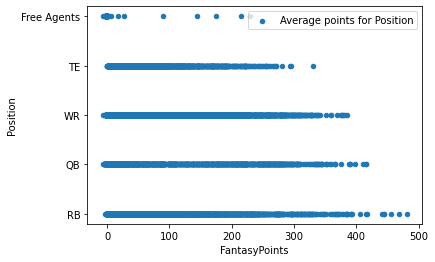

<Figure size 2880x2880 with 0 Axes>

In [17]:
#Scatter plot for Average points scored for each position 
ax = newnfl.plot.scatter(x='FantasyPoints', y='Position', label ='Average points for Position')
plt.figure(figsize =(40,40))

<Figure size 720x720 with 0 Axes>

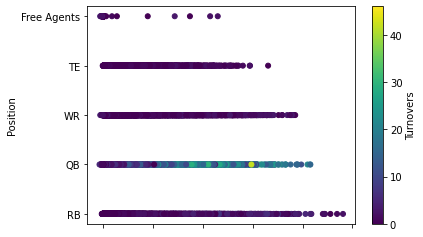

<Figure size 720x720 with 0 Axes>

In [18]:
#Scatter plot to compare the turnover affects by Fantasy Points
newnfl.plot.scatter(x='FantasyPoints', y='Position', c='Turnovers', colormap="viridis", s=25) 
plt.figure(figsize =(10,10))

In [19]:
#Creating a new dataframe for only QB with the specific columns needs for Analysis 
dfqb = newnfl.loc[newnfl['Position'] ==  'QB', ['Position','Player','FantasyPoints', 'Fumbles', 'Interception']] #Dataframe for QB and using column "Position", "Player", "FantasyPoints", "Fumbles", "Interception", "Turnovers"
dfqb['Turnovers'] = dfqb['Fumbles'] + dfqb['Interception'] #Add a new column as "Turnovers" by appending fumbles column and interception column together
dfqb.sort_values(by='FantasyPoints') #Sort values by Fantasy Points
dfqb.sort_values(by =['FantasyPoints'], ascending =False) #sorting the values from largest to smallest

,Position,Player,FantasyPoints,Fumbles,Interception,Turnovers
1,QB,Lamar Jackson,415.68,9.0,6.0,15.0
4,QB,Patrick Mahomes,415.08,9.0,12.0,21.0
1,QB,Peyton Manning,409.98,11.0,10.0,21.0
0,QB,Aaron Rodgers,397.42,5.0,6.0,11.0
0,QB,Tom Brady,390.04,6.0,8.0,14.0
...,...,...,...,...,...,...
540,QB,Scott Mitchell,-4.48,0.0,3.0,3.0
585,QB,Alex Van Pelt,-4.64,0.0,3.0,3.0
577,QB,Bruce Gradkowski,-4.76,0.0,3.0,3.0
584,QB,Chris Redman,-5.28,3.0,2.0,5.0


# QB Position

I did the QB position because it the most important position in the NFL and more pressure is on the QB 

<Figure size 2160x2160 with 0 Axes>

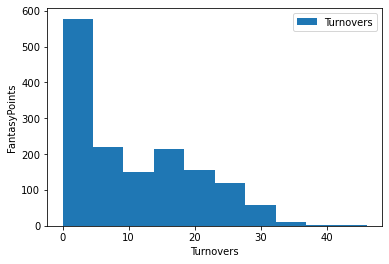

<Figure size 2160x2160 with 0 Axes>

In [20]:
#Histogram for fantasy points QB scored compared to turnovers
qb = dfqb.plot(x='FantasyPoints', y='Turnovers', kind= 'hist')
qb.set_xlabel('Turnovers')
qb.set_ylabel("FantasyPoints")
plt.figure(figsize = (30, 30))

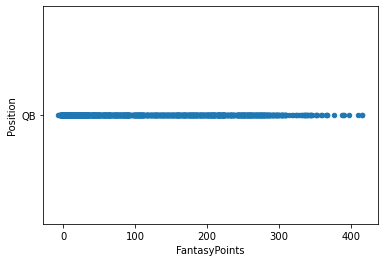

In [21]:
#Scatter plot for fantasy points scored for QB 
qb = dfqb.plot.scatter(x='FantasyPoints', y='Position')

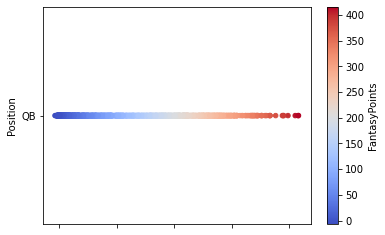

In [22]:
#Scatter plots for fantasypoints scored for QB dataframe with colorlabel and points
qbto = dfqb.plot.scatter(x='FantasyPoints', y='Position', c='FantasyPoints', colormap="coolwarm")

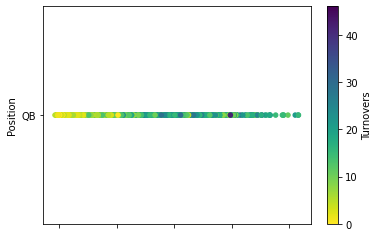

In [23]:
#Scatter plot for Turnovers for the QB by fantasypoints 
qbto = dfqb.plot.scatter(x='FantasyPoints', y='Position', c='Turnovers', colormap="viridis_r")

# Is there a decrease or increase in fantasy stats over the last decade for each position? 

In [24]:
#Creating all separte dataframe for each skill positions "QB", "RB", 'WR', 'TE', and using "Turnovers" and "Fantasy Points" columns 
df_qb = newnfl[newnfl['Position'] == 'QB']
df_rb = newnfl[newnfl['Position'] == 'RB']
df_wr = newnfl[newnfl['Position'] == 'WR']
df_te = newnfl[newnfl['Position'] == 'TE']
df_to = newnfl['Turnovers']
df_point = newnfl[['FantasyPoints']]

In [25]:
#Display each dataframe created above for each position 
#df_qb.head()
#df_rb.head()
#df_wr.head()
df_te.head()

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
6,Tony Gonzalez,TE,KAN,0.0,0.0,0.0,0.0,0.0,150.0,93.0,1203.0,9.0,0.0,0.0,0.0,267.30,0.0
37,Shannon Sharpe,TE,BAL,0.0,0.0,0.0,0.0,0.0,105.0,67.0,810.0,5.0,0.0,0.0,0.0,178.00,0.0
39,Freddie Jones,TE,SDG,0.0,0.0,0.0,0.0,0.0,126.0,71.0,766.0,5.0,0.0,0.0,3.0,173.60,3.0
45,Frank Wycheck,TE,TEN,2.0,2.0,53.0,1.0,0.0,109.0,70.0,636.0,4.0,0.0,0.0,2.0,157.72,2.0
47,Kyle Brady,TE,JAX,0.0,0.0,0.0,0.0,0.0,94.0,64.0,729.0,3.0,0.0,0.0,0.0,154.90,0.0


In [26]:
#Creating a new dataframe for only skill positions by concatting all the dataframe above into one
newpos = pd.concat([df_qb, df_rb, df_wr, df_te, df_point])
newpos.sample(5)

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,320.90,NaN
392,Kellen Davis,TE,CHI,0.0,0.0,0.0,0.0,0.0,2.0,1.0,19.0,1.0,0.0,0.0,0.0,8.90,0.0
443,Allen Reisner,TE,JAX,0.0,0.0,0.0,0.0,0.0,9.0,5.0,40.0,0.0,0.0,0.0,0.0,9.00,0.0
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.66,NaN
465,Brandon Middleton,WR,DET,0.0,0.0,0.0,0.0,0.0,3.0,1.0,23.0,0.0,0.0,0.0,3.0,3.30,3.0


source: https://miamioh.instructure.com/courses/38817/pages/data-cleaning#:~:text=The%20function%20dataframe.-,isnull().,values%20in%20the%20data%20set.&text=A%20simple%20way%20to%20deal,missing%20values%20in%20the%20dataset.

In [27]:
#Checking for missing values - Note there might NaN valuess from the Free Agents column because I am not using it..
newpos.isnull().sum()

Player           11900
Position         11900
Team             11900
Attempt          11900
Completions      11900
PassingYds       11900
PassingTD        11900
Interception     11900
Target           11900
Receptions       11900
ReceivingYds     11900
ReceivingTD      11900
RushingYds       11900
RushingTD        11900
Fumbles          11900
FantasyPoints        0
Turnovers        11900
dtype: int64

In [28]:
#Total number of missing values
newpos.isnull().sum().sum()

190400

# Created a new Dataframe for Analysis 

In [29]:
#New dataframe for above and dropping all missing values
dfpos = newpos
dfpos = dfpos.dropna() #Drop all NaN values, which are Free Agents because I want to use skill positions only 
dfpos

,Player,Position,Team,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
2,Daunte Culpepper,QB,MIN,474.0,297.0,3937.0,33.0,16.0,0.0,0.0,0.0,0.0,470.0,7.0,11.0,334.48,27.0
3,Jeff Garcia,QB,SFO,561.0,355.0,4278.0,31.0,10.0,0.0,0.0,0.0,0.0,414.0,4.0,7.0,338.52,17.0
11,Rich Gannon,QB,OAK,473.0,284.0,3430.0,28.0,11.0,0.0,0.0,0.0,0.0,529.0,4.0,9.0,294.10,20.0
13,Peyton Manning,QB,IND,571.0,357.0,4413.0,33.0,15.0,0.0,0.0,0.0,0.0,116.0,1.0,5.0,290.12,20.0
18,Donovan McNabb,QB,PHI,569.0,330.0,3365.0,21.0,13.0,4.0,2.0,5.0,0.0,629.0,6.0,7.0,286.00,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,Levine Toilolo,TE,SFO,0.0,0.0,0.0,0.0,0.0,2.0,2.0,10.0,0.0,0.0,0.0,0.0,3.00,0.0
548,Darrell Daniels,TE,ARI,0.0,0.0,0.0,0.0,0.0,3.0,1.0,4.0,0.0,0.0,0.0,0.0,1.40,0.0
561,Zach Gentry,TE,PIT,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,1.40,0.0
566,Xavier Grimble,TE,PIT,0.0,0.0,0.0,0.0,0.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,1.30,0.0


In [30]:
#Checking if the missing values are dropped because I am not using the dataset for Free Agents
dfpos.isnull().sum()

#Missing values are dropped

Player           0
Position         0
Team             0
Attempt          0
Completions      0
PassingYds       0
PassingTD        0
Interception     0
Target           0
Receptions       0
ReceivingYds     0
ReceivingTD      0
RushingYds       0
RushingTD        0
Fumbles          0
FantasyPoints    0
Turnovers        0
dtype: int64

Using the specific columns to find the trends of Fantasy stats over the past decade. <br> 
source: https://cmdlinetips.com/2019/01/how-to-make-heatmap-with-seaborn-in-python/ <br> 
source: https://www.delftstack.com/howto/seaborn/rotate-tick-labels-seaborn/ <br> 
source: https://www.geeksforgeeks.org/python-pandas-dataframe-corr/

In [31]:
#Attempting to find the correlation between each stat
n = newpos.corr()
n

,Attempt,Completions,PassingYds,PassingTD,Interception,Target,Receptions,ReceivingYds,ReceivingTD,RushingYds,RushingTD,Fumbles,FantasyPoints,Turnovers
Attempt,1.000000,0.997229,0.993890,0.955516,0.933360,-0.240746,-0.240692,-0.214293,-0.170430,0.030266,0.075923,0.736311,0.384410,0.917736
Completions,0.997229,1.000000,0.996588,0.964489,0.919346,-0.236825,-0.236757,-0.210819,-0.167631,0.029364,0.075555,0.724352,0.391603,0.903558
PassingYds,0.993890,0.996588,1.000000,0.973077,0.914892,-0.234674,-0.234626,-0.208864,-0.166106,0.031447,0.078494,0.722190,0.398227,0.899774
PassingTD,0.955516,0.964489,0.973077,1.000000,0.857943,-0.217266,-0.217047,-0.193472,-0.153934,0.036332,0.079345,0.679051,0.414340,0.844566
Interception,0.933360,0.919346,0.914892,0.857943,1.000000,-0.238388,-0.238348,-0.212123,-0.168624,0.019557,0.060765,0.717278,0.320368,0.951713
Target,-0.240746,-0.236825,-0.234674,-0.217266,-0.238388,1.000000,0.980493,0.970370,0.804617,0.060857,0.034422,-0.062306,0.672904,-0.178993
Receptions,-0.240692,-0.236757,-0.234626,-0.217047,-0.238348,0.980493,1.000000,0.958463,0.791092,0.133084,0.096026,-0.041304,0.703736,-0.169714
ReceivingYds,-0.214293,-0.210819,-0.208864,-0.193472,-0.212123,0.970370,0.958463,1.000000,0.845227,-0.001452,-0.014555,-0.060222,0.671214,-0.161378
ReceivingTD,-0.170430,-0.167631,-0.166106,-0.153934,-0.168624,0.804617,0.791092,0.845227,1.000000,-0.079389,-0.072849,-0.080190,0.582179,-0.142523
RushingYds,0.030266,0.029364,0.031447,0.036332,0.019557,0.060857,0.133084,-0.001452,-0.079389,1.000000,0.868165,0.307185,0.486975,0.147772


<AxesSubplot:>

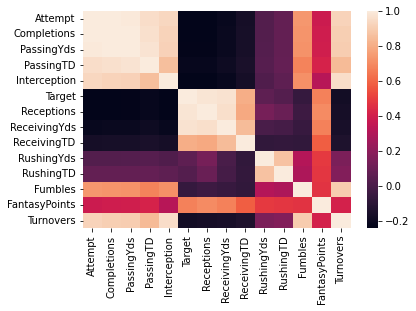

In [32]:
#Create a heatmap for newpos dataframe and the correlation
sns.heatmap(newpos.corr())

In [33]:
#Create a new dataframe but only using the positions not Free Agents
stats = dfpos[['Player','Position', 'Team','FantasyPoints', 'Turnovers']]
stats

,Player,Position,Team,FantasyPoints,Turnovers
2,Daunte Culpepper,QB,MIN,334.48,27.0
3,Jeff Garcia,QB,SFO,338.52,17.0
11,Rich Gannon,QB,OAK,294.10,20.0
13,Peyton Manning,QB,IND,290.12,20.0
18,Donovan McNabb,QB,PHI,286.00,20.0
...,...,...,...,...,...
532,Levine Toilolo,TE,SFO,3.00,0.0
548,Darrell Daniels,TE,ARI,1.40,0.0
561,Zach Gentry,TE,PIT,1.40,0.0
566,Xavier Grimble,TE,PIT,1.30,0.0


In [34]:
#Creating a heatmap for position and the correlation of fantasy points scored 
newstat = pd.pivot_table(stats, values ='FantasyPoints', index=['Position'], columns ='Team')

[Text(0, 0.5, 'QB'),
 Text(0, 1.5, 'RB'),
 Text(0, 2.5, 'TE'),
 Text(0, 3.5, 'WR')]

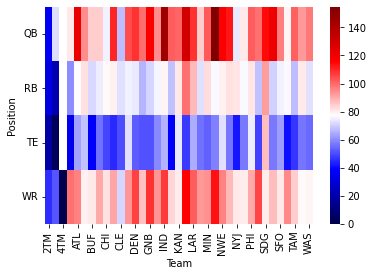

In [35]:
#Displaying the heatmap and displaying if it Decrease or increase for each position by fantasy points and team over the decade
ax = sns.heatmap(newstat, cmap="seismic")
ax.set_yticklabels(ax.get_yticklabels(),rotation = 0)
#ax.set_xticklabels(ax.get_xticklabels(),rotation = 0) looks weird when its aligned straightly

Based on my analysis, for the QB position fantasy points has increased along with RB and WR drastically for each team. However, for TE position it increased but very little over the decade. 

# Is there a similarity in points scored for each position over the decade?

source: https://matplotlib.org/3.5.1/tutorials/colors/colormaps.html (thought this was cool)  <br> 
source: https://github.com/pandas-dev/pandas/issues/21963 

In [36]:
#Average (sum) points scored for each position over the decade 
allpos = newpos.groupby(newpos['Position'])['FantasyPoints'].sum()
allpos

Position
QB    148980.62
RB    239991.26
TE    104846.56
WR    331652.60
Name: FantasyPoints, dtype: float64

In [37]:
#Changed the values to a string because I was getting an error for the scatter plot below
#dfpos = dfpos.astype(str)

Position
QB    AxesSubplot(0.125,0.125;0.62x0.755)
RB    AxesSubplot(0.125,0.125;0.62x0.755)
TE    AxesSubplot(0.125,0.125;0.62x0.755)
WR    AxesSubplot(0.125,0.125;0.62x0.755)
dtype: object

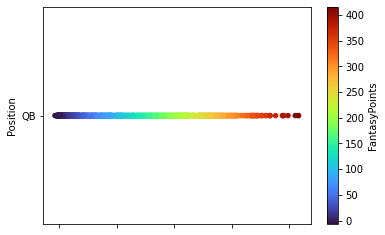

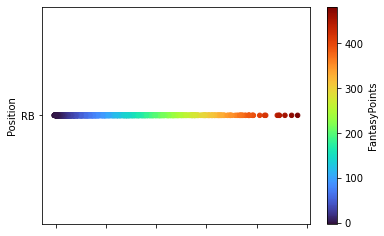

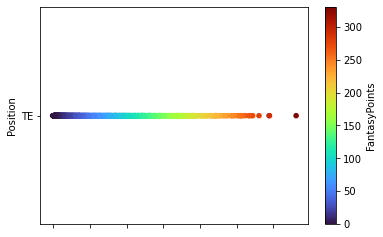

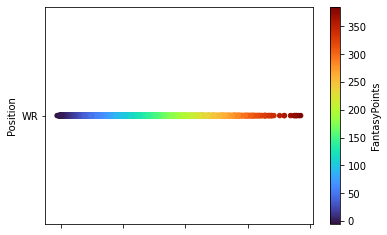

In [38]:
#Create a scatter plot for dfpos Fantasy Points scored for each position over the decade but groupby "Position"
dfpos.groupby('Position').plot.scatter(x='FantasyPoints', y='Position', c='FantasyPoints', cmap ='turbo')

<Figure size 2880x2880 with 0 Axes>

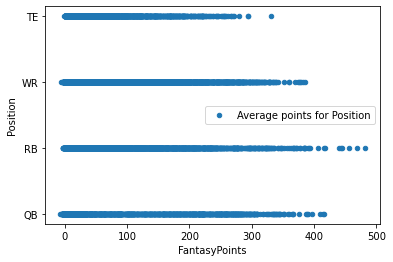

<Figure size 2880x2880 with 0 Axes>

In [39]:
#Create a Scatter plot for the points scored for each position with the new dataframe dfpos 
ax = dfpos.plot.scatter(x='FantasyPoints', y='Position', label ='Average points for Position')
plt.figure(figsize =(40,40))

Text(0, 0.5, 'Position')

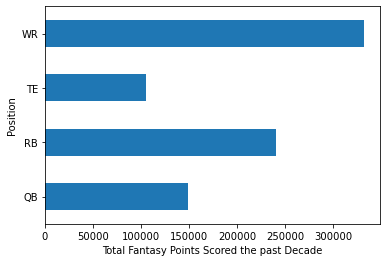

In [40]:
#Created a hbarplot for the total number of points scored over the decade; groupby position and the sum of fantasy points
newpos.groupby(newpos['Position'])['FantasyPoints'].sum().plot(kind='barh')
plt.xlabel('Total Fantasy Points Scored the past Decade')
plt.ylabel('Position')